# *Meta-labeling shortlist*: robustez fold-level del efecto meta (Exp1.5)

Complemento de `03_evidencia_shortlist_meta_labeling.ipynb` sobre la corrida canónica `disabled_gate_best_per_family_with_fallback` (panel `5` símbolos × `3` métodos, hasta `2` candidatos por celda). Solo lectura: consume los JSON ya persistidos bajo `reports/validation/experiments/advanced_studies/meta_labeling_shortlist_*.json` y escribe tablas y figuras en el mismo manifest que el notebook `03` (`reports/validation/experiments/meta_labeling_shortlist_evidence/`).

El notebook `03` resume el efecto **agregado** por celda (`media_delta_sharpe`, `media_meta_f1`, `media_ratio_cobertura`). Aquí se baja una capa: cada `meta_labeling_summary.aggregate_comparison.fold_traceability_rows[].comparison` aporta una observación por fold, y se audita la **estabilidad temporal** de ese efecto.

| Pregunta | Cómo se ataca |
| --- | --- |
| ¿Es estable el `delta_sharpe` **por fold** o viene de pocos folds extremos? | Resumen de dispersión (mediana, IQR, porcentaje de folds con `delta_sharpe > 0`), boxplots y heatmaps por celda y familia primaria. |
| ¿Se mueven juntos primario elegible y meta filtrado, o el meta-filtro altera el régimen? | Trayectorias fold de `primary_eligible_sharpe` vs `meta_filtered_sharpe` por celda. |
| Cuando una misma celda completa dos familias primarias (`xgboost`, `lstm`), ¿difieren las distribuciones fold de `delta_sharpe`? | Wilcoxon pareado fold a fold entre familias dentro de la celda. |


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _find_repo_root() -> Path:
    cur = Path.cwd().resolve()
    while cur != cur.parent and not (cur / "src").is_dir():
        cur = cur.parent
    if not (cur / "src").is_dir():
        raise FileNotFoundError("No se encontró la raíz del repo (carpeta src/).")
    return cur


_loaders_dir = _find_repo_root() / "evidence_utils"
if str(_loaders_dir) not in sys.path:
    sys.path.insert(0, str(_loaders_dir))

from meta_labeling_shortlist_loaders import (
    EXPECTED_METHODS,
    EXPECTED_SYMBOLS,
    META_LABELING_SHORTLIST_DEFINITIVE_RUNS,
    ensure_evidence_dirs,
    index_definitive_payloads,
    keep_latest_run_per_cell,
    locate_repo_root,
    resolve_advanced_dir,
)

CANONICAL_RUN_KEY = "disabled_gate_best_per_family_with_fallback"
CANONICAL_RUN = next(
    run for run in META_LABELING_SHORTLIST_DEFINITIVE_RUNS if run.key == CANONICAL_RUN_KEY
)

COLUMNAS_ES = {
    "symbol": "simbolo",
    "method": "metodo",
    "primary_family": "familia_primaria",
    "family_a": "familia_a",
    "family_b": "familia_b",
    "fold": "fold",
    "n_folds": "n_folds",
    "n_pairs": "n_pares",
    "delta_sharpe": "delta_sharpe",
    "primary_eligible_sharpe": "sharpe_primario_elegible",
    "meta_filtered_sharpe": "sharpe_meta_filtrado",
    "meta_f1": "meta_f1",
    "coverage_ratio": "ratio_cobertura",
    "filter_ratio": "ratio_filtrado",
    "delta_total_return": "delta_retorno_total",
    "delta_sharpe_median": "delta_sharpe_mediana",
    "delta_sharpe_iqr": "delta_sharpe_iqr",
    "delta_sharpe_mean": "delta_sharpe_media",
    "delta_sharpe_std": "delta_sharpe_desv",
    "pct_folds_delta_pos": "pct_folds_delta_positivo",
    "coverage_ratio_median": "ratio_cobertura_mediana",
    "meta_f1_median": "meta_f1_mediana",
    "statistic": "estadistico",
    "p_value": "p_valor",
    "median_diff_a_minus_b": "diff_mediana_a_menos_b",
    "verdict": "veredicto",
    "status": "estado",
}


def _es(label):
    if isinstance(label, tuple):
        return tuple(COLUMNAS_ES.get(str(p), str(p)) for p in label)
    return COLUMNAS_ES.get(str(label), str(label))


def display_es(frame):
    if isinstance(frame, pd.Series):
        frame = frame.to_frame()
    vista = frame.copy()
    vista.columns = [_es(c) for c in vista.columns]
    if vista.index.names and any(n is not None for n in vista.index.names):
        vista.index = vista.index.set_names([None if n is None else _es(n) for n in vista.index.names])
    display(vista)


pd.set_option("display.max_columns", 80)
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = locate_repo_root()
ADVANCED_DIR = resolve_advanced_dir(ROOT)
EVIDENCE_DIR, TABLE_DIR, FIGURE_DIR = ensure_evidence_dirs(ROOT)
FIG_FOLD = FIGURE_DIR / "fold_meta_robustness"
for sub in ("boxplots", "heatmaps", "lineplots"):
    (FIG_FOLD / sub).mkdir(parents=True, exist_ok=True)

print(f"RAIZ={ROOT}")
print(f"DIR_EVIDENCIA={EVIDENCE_DIR}")
print(f"figuras de robustez fold meta -> {FIG_FOLD}")


RAIZ=/app
DIR_EVIDENCIA=/app/reports/validation/experiments/meta_labeling_shortlist_evidence
figuras de robustez fold meta -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness


## 1. Carga reproducible de la corrida canónica

Se reutiliza `index_definitive_payloads` (mismo dedup que en `03`) y se filtra al `campaign == "disabled_gate_best_per_family_with_fallback"`. El conjunto resultante debe abarcar las `15` celdas esperadas del panel; cualquier celda ausente se reporta y queda fuera del análisis fold-level.


In [3]:
indice_df, payloads = index_definitive_payloads(ADVANCED_DIR, repo_root=ROOT)
indice_df = keep_latest_run_per_cell(indice_df)
indice_canonico = indice_df[indice_df["campaign"] == CANONICAL_RUN_KEY].copy()

celdas_presentes = set(zip(indice_canonico["symbol"], indice_canonico["method"]))
celdas_esperadas = {(s, m) for s in EXPECTED_SYMBOLS for m in EXPECTED_METHODS}
celdas_faltantes = sorted(celdas_esperadas - celdas_presentes)

print(f"Celdas presentes en la corrida canónica: {len(celdas_presentes)} / {len(celdas_esperadas)}")
if celdas_faltantes:
    print("Celdas ausentes (no entran en el analisis fold-level):")
    for s, m in celdas_faltantes:
        print(f"  - {s} / {m}")

display_es(indice_canonico[["symbol", "method", "n_candidates", "n_completed", "n_not_executable"]].reset_index(drop=True))


Celdas presentes en la corrida canónica: 15 / 15


,simbolo,metodo,n_candidates,n_completed,n_not_executable
0,BTCUSDT,triple_barrier,2,2,0
1,BTCUSDT,trend_scanning,2,2,0
2,ETHUSDT,triple_barrier,2,2,0
3,ETHUSDT,trend_scanning,2,2,0
4,ETHUSDT,fixed_horizon,2,2,0
5,BNBUSDT,triple_barrier,2,2,0
6,BNBUSDT,trend_scanning,2,2,0
7,BNBUSDT,fixed_horizon,2,2,0
8,XRPUSDT,triple_barrier,2,2,0
9,XRPUSDT,trend_scanning,2,2,0


## 2. Extracción fold-level

Por cada `(símbolo, método)` se recorren los `results[]` con `status == "completed"`, se identifica la `primary_family` real del candidato y se aplanan los `meta_labeling_summary.aggregate_comparison.fold_traceability_rows[].comparison` en una fila por fold. Solo se conservan folds con `comparison_available == True`.

El resultado `fold_rows` es la materia prima común de las secciones 3 a 7.


In [4]:
CAMPOS_COMPARACION = (
    "delta_sharpe",
    "primary_eligible_sharpe",
    "meta_filtered_sharpe",
    "meta_f1",
    "coverage_ratio",
    "filter_ratio",
    "delta_total_return",
)
COLUMNAS_FOLD = ["symbol", "method", "primary_family", "fold", *CAMPOS_COMPARACION]


def extraer_fold_rows(payload_index, run_rows: pd.DataFrame) -> pd.DataFrame:
    filas = []
    for _, run_meta in run_rows.iterrows():
        payload = payload_index[
            (run_meta["campaign"], run_meta["symbol"], run_meta["method"])
        ]
        for resultado in payload.get("results") or []:
            if (resultado.get("status") or "").lower() != "completed":
                continue
            candidato = (resultado.get("candidate") or {})
            familia = (
                resultado.get("primary_family")
                or candidato.get("family")
                or "unknown"
            )
            resumen = resultado.get("meta_labeling_summary") or {}
            agregado = resumen.get("aggregate_comparison") or {}
            trazas = agregado.get("fold_traceability_rows") or []
            for traza in trazas:
                comparacion = traza.get("comparison") or {}
                if not comparacion.get("comparison_available"):
                    continue
                fila = {
                    "symbol": run_meta["symbol"],
                    "method": run_meta["method"],
                    "primary_family": familia,
                    "fold": traza.get("outer_fold_id"),
                }
                for campo in CAMPOS_COMPARACION:
                    fila[campo] = comparacion.get(campo)
                filas.append(fila)
    if not filas:
        return pd.DataFrame(columns=COLUMNAS_FOLD)
    return pd.DataFrame(filas)


fold_rows = extraer_fold_rows(payloads, indice_canonico)
if fold_rows.empty:
    raise RuntimeError(
        "No se extrajeron filas fold-level. Revisa que los JSON tengan "
        "meta_labeling_summary.aggregate_comparison.fold_traceability_rows."
    )
fold_rows = fold_rows.sort_values(["symbol", "method", "primary_family", "fold"]).reset_index(drop=True)
print(f"Filas fold-level: {len(fold_rows)}")
print("Familias primarias observadas:", sorted(fold_rows["primary_family"].dropna().unique()))
display_es(fold_rows.head(8))


Filas fold-level: 2010
Familias primarias observadas: ['lstm', 'xgboost']


,simbolo,metodo,familia_primaria,fold,delta_sharpe,sharpe_primario_elegible,sharpe_meta_filtrado,meta_f1,ratio_cobertura,ratio_filtrado,delta_retorno_total
0,BNBUSDT,fixed_horizon,lstm,0,0.1398,-0.0589,0.0809,0.0435,0.0111,0.9889,0.7207
1,BNBUSDT,fixed_horizon,lstm,1,0.0000,0.0195,0.0195,0.7143,1.0000,0.0000,0.0000
2,BNBUSDT,fixed_horizon,lstm,2,0.0000,-0.0277,-0.0277,0.6765,1.0000,0.0000,0.0000
3,BNBUSDT,fixed_horizon,lstm,3,0.0000,-0.1054,-0.1054,0.6765,1.0000,0.0000,0.0000
4,BNBUSDT,fixed_horizon,lstm,4,-0.1559,-0.0642,-0.2202,0.3108,0.3333,0.6667,-0.5633
5,BNBUSDT,fixed_horizon,lstm,5,0.0000,0.0654,0.0654,0.7004,1.0000,0.0000,0.0000
6,BNBUSDT,fixed_horizon,lstm,6,-0.2965,0.1727,-0.1238,0.2238,0.2558,0.7442,-2.2561
7,BNBUSDT,fixed_horizon,lstm,7,-0.1023,0.1023,0.0000,0.0000,0.0000,1.0000,-1.2795


## 3. Resumen de dispersión por (celda, familia primaria)

Para cada combinación `(símbolo, método, familia_primaria)` se resumen los folds con: número de folds, mediana e IQR del `delta_sharpe`, media y desviación, fracción de folds con `delta_sharpe > 0`, y mediana de `coverage_ratio` y `meta_f1` (referencia de cuánto **opera** el meta-filtro y con qué calidad).

Se exporta a `tables/meta_labeling_shortlist_fold_delta_summary.csv`. El criterio prudente del notebook `03` (delta agregado pequeño y heterogéneo) se contrasta aquí con la dispersión fold a fold.


In [5]:
def resumir_celda_familia(grupo):
    delta = grupo["delta_sharpe"].dropna()
    n = int(len(delta))
    if n == 0:
        return pd.Series({
            "n_folds": 0,
            "delta_sharpe_median": np.nan,
            "delta_sharpe_iqr": np.nan,
            "delta_sharpe_mean": np.nan,
            "delta_sharpe_std": np.nan,
            "pct_folds_delta_pos": np.nan,
            "coverage_ratio_median": np.nan,
            "meta_f1_median": np.nan,
        })
    q1, q3 = np.nanpercentile(delta, [25, 75])
    return pd.Series({
        "n_folds": n,
        "delta_sharpe_median": float(np.nanmedian(delta)),
        "delta_sharpe_iqr": float(q3 - q1),
        "delta_sharpe_mean": float(np.nanmean(delta)),
        "delta_sharpe_std": float(np.nanstd(delta, ddof=1)) if n > 1 else 0.0,
        "pct_folds_delta_pos": float((delta > 0).mean() * 100.0),
        "coverage_ratio_median": float(np.nanmedian(grupo["coverage_ratio"])),
        "meta_f1_median": float(np.nanmedian(grupo["meta_f1"])),
    })


resumen_fold = (
    fold_rows.groupby(["symbol", "method", "primary_family"], dropna=False)
    .apply(resumir_celda_familia, include_groups=False)
    .reset_index()
)

csv_resumen = TABLE_DIR / "meta_labeling_shortlist_fold_delta_summary.csv"
resumen_fold.to_csv(csv_resumen, index=False)
print(f"CSV escrito: {csv_resumen}")
display_es(resumen_fold)


CSV escrito: /app/reports/validation/experiments/meta_labeling_shortlist_evidence/tables/meta_labeling_shortlist_fold_delta_summary.csv


,simbolo,metodo,familia_primaria,n_folds,delta_sharpe_mediana,delta_sharpe_iqr,delta_sharpe_media,delta_sharpe_desv,pct_folds_delta_positivo,ratio_cobertura_mediana,meta_f1_mediana
0,BNBUSDT,fixed_horizon,lstm,95.0000,0.0000,0.0847,-0.0135,0.1232,43.1579,0.6778,0.5161
1,BNBUSDT,fixed_horizon,xgboost,95.0000,0.0054,0.0965,0.0167,0.0825,54.7368,0.5500,0.5275
2,BNBUSDT,trend_scanning,lstm,95.0000,0.0000,0.0695,-0.0240,0.1680,38.9474,0.7944,0.5845
3,BNBUSDT,trend_scanning,xgboost,95.0000,-0.0126,0.1183,0.0170,0.1556,43.1579,0.6167,0.5674
4,BNBUSDT,triple_barrier,lstm,29.0000,0.0022,0.0342,0.0184,0.0525,51.7241,0.4111,0.4746
5,BNBUSDT,triple_barrier,xgboost,29.0000,-0.0106,0.0429,-0.0047,0.0554,34.4828,0.6500,0.5662
6,BTCUSDT,fixed_horizon,lstm,95.0000,0.0000,0.0976,0.0002,0.1524,36.8421,0.4938,0.4918
7,BTCUSDT,fixed_horizon,xgboost,97.0000,0.0077,0.1062,0.0249,0.0984,54.6392,0.5819,0.5258
8,BTCUSDT,trend_scanning,lstm,97.0000,-0.0168,0.1442,-0.0192,0.1576,37.1134,0.5722,0.5026
9,BTCUSDT,trend_scanning,xgboost,97.0000,-0.0028,0.0937,0.0020,0.0899,48.4536,0.7056,0.5830


## 4. Boxplots del `delta_sharpe` fold a fold

Una figura por símbolo, con un boxplot por `(método, familia_primaria)`. El cero está marcado en rojo: cajas que cruzan el cero de forma simétrica indican efecto meta neutro a nivel de fold; sesgos claros hacia arriba o abajo señalan régimen consistente.


figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/boxplots/delta_sharpe_box_btcusdt.png


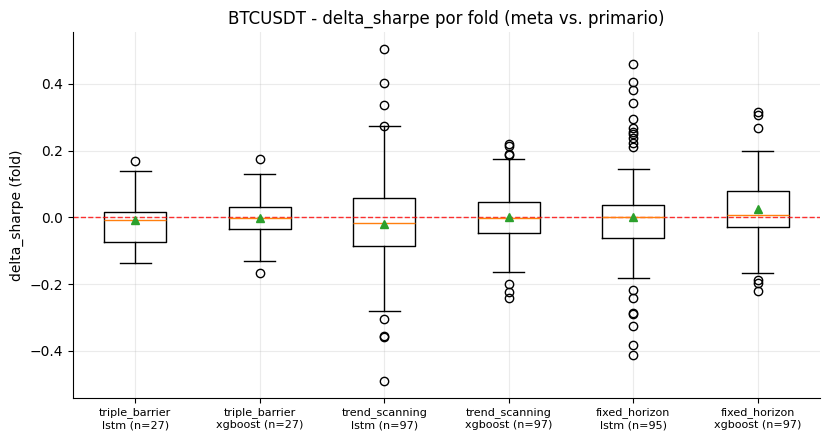

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/boxplots/delta_sharpe_box_ethusdt.png


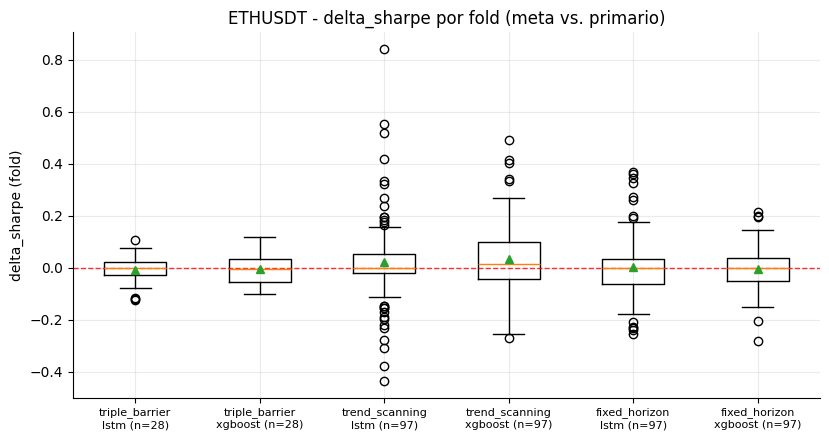

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/boxplots/delta_sharpe_box_bnbusdt.png


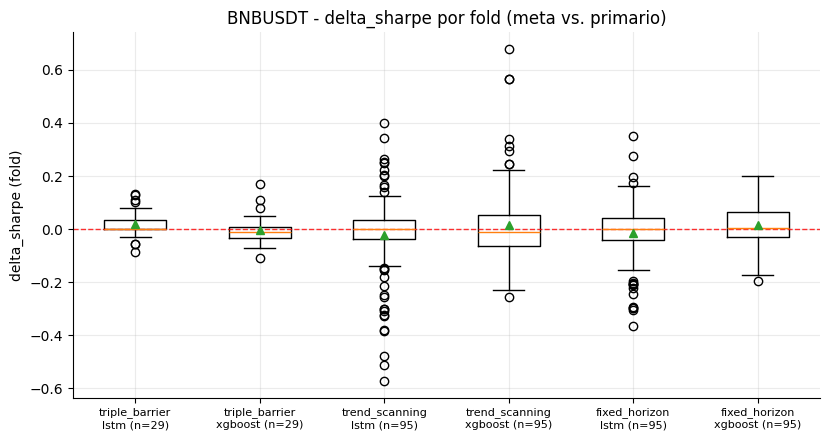

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/boxplots/delta_sharpe_box_xrpusdt.png


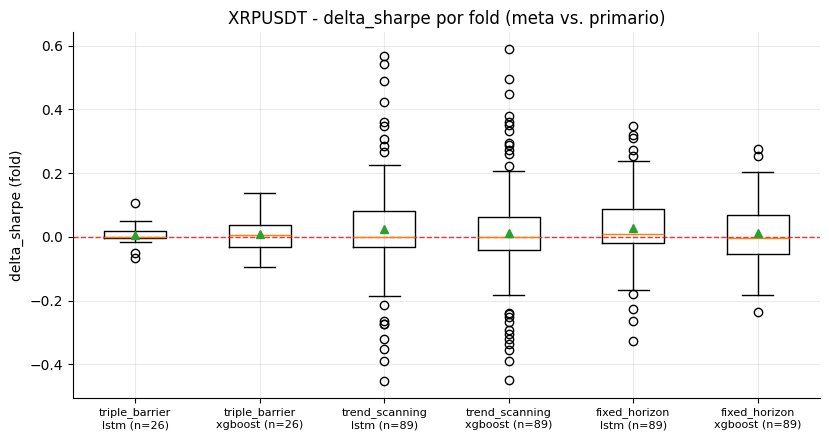

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/boxplots/delta_sharpe_box_solusdt.png


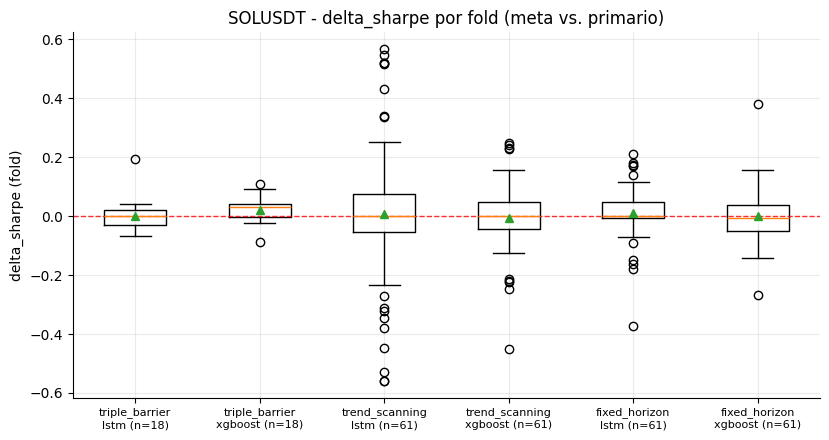

In [6]:
def boxplot_por_simbolo(df_fold: pd.DataFrame, simbolo: str):
    sub = df_fold[df_fold["symbol"] == simbolo]
    if sub.empty:
        return None
    grupos = []
    etiquetas = []
    for metodo in EXPECTED_METHODS:
        for familia in sorted(sub["primary_family"].dropna().unique()):
            datos = sub[(sub["method"] == metodo) & (sub["primary_family"] == familia)]["delta_sharpe"].dropna().to_numpy()
            if datos.size == 0:
                continue
            grupos.append(datos)
            etiquetas.append(f"{metodo}\n{familia} (n={datos.size})")
    if not grupos:
        return None
    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(grupos)), 4.5))
    ax.boxplot(grupos, tick_labels=etiquetas, showmeans=True)
    ax.axhline(0.0, color="red", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_title(f"{simbolo} - delta_sharpe por fold (meta vs. primario)")
    ax.set_ylabel("delta_sharpe (fold)")
    ax.tick_params(axis="x", rotation=0, labelsize=8)
    fig.tight_layout()
    destino = FIG_FOLD / "boxplots" / f"delta_sharpe_box_{simbolo.lower()}.png"
    fig.savefig(destino, dpi=160)
    return fig, destino


for simbolo in EXPECTED_SYMBOLS:
    resultado = boxplot_por_simbolo(fold_rows, simbolo)
    if resultado is None:
        print(f"{simbolo}: sin datos fold-level")
        continue
    fig, destino = resultado
    print(f"figura guardada -> {destino}")
    plt.show()


**Lectura.** Cajas centradas en cero con bigotes amplios reflejan el patrón anticipado en `03`: el meta-filtro aporta ocasionalmente folds favorables y ocasionalmente desfavorables, sin un sesgo direccional fuerte. Cuando una caja se aleja del cero de forma persistente, esa celda merece inspección puntual (ver tabla de la sección 3 y heatmap de la sección 5).


## 5. Heatmap de la mediana de `delta_sharpe` por celda

Un heatmap por familia primaria con filas = símbolo, columnas = método, valor = mediana fold-level de `delta_sharpe`. Sirve como mapa rápido de qué celdas tienen efecto meta sistemáticamente positivo, neutro o negativo (en mediana, robusto a colas).


figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/heatmaps/delta_sharpe_median_heatmap_lstm.png


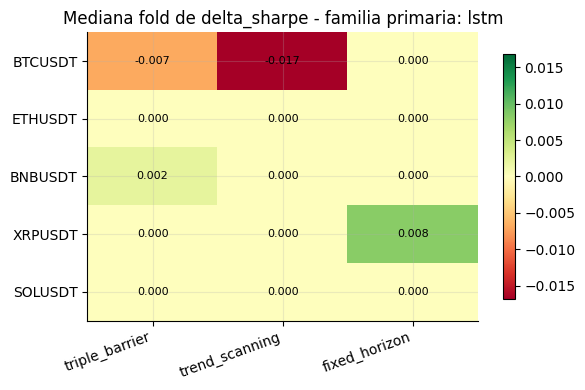

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/heatmaps/delta_sharpe_median_heatmap_xgboost.png


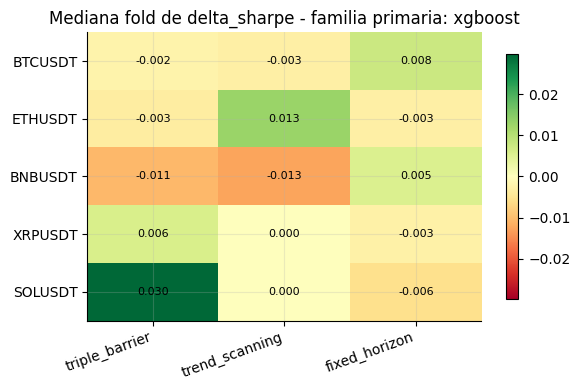

In [7]:
def heatmap_mediana(df_resumen: pd.DataFrame, familia: str):
    sub = df_resumen[df_resumen["primary_family"] == familia]
    if sub.empty:
        return None
    matriz = (
        sub.pivot(index="symbol", columns="method", values="delta_sharpe_median")
        .reindex(index=EXPECTED_SYMBOLS, columns=EXPECTED_METHODS)
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    valores = matriz.to_numpy(dtype=float)
    limite = float(np.nanmax(np.abs(valores))) if np.isfinite(valores).any() else 1.0
    limite = limite if limite > 0 else 1.0
    img = ax.imshow(valores, cmap="RdYlGn", vmin=-limite, vmax=limite, aspect="auto")
    ax.set_xticks(range(len(EXPECTED_METHODS)))
    ax.set_xticklabels(EXPECTED_METHODS, rotation=20, ha="right")
    ax.set_yticks(range(len(EXPECTED_SYMBOLS)))
    ax.set_yticklabels(EXPECTED_SYMBOLS)
    for i in range(valores.shape[0]):
        for j in range(valores.shape[1]):
            v = valores[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8, color="black")
    ax.set_title(f"Mediana fold de delta_sharpe - familia primaria: {familia}")
    fig.colorbar(img, ax=ax, shrink=0.85)
    fig.tight_layout()
    destino = FIG_FOLD / "heatmaps" / f"delta_sharpe_median_heatmap_{familia}.png"
    fig.savefig(destino, dpi=160)
    return fig, destino


for familia in sorted(resumen_fold["primary_family"].dropna().unique()):
    resultado = heatmap_mediana(resumen_fold, familia)
    if resultado is None:
        continue
    fig, destino = resultado
    print(f"figura guardada -> {destino}")
    plt.show()


## 6. Trayectorias fold: primario elegible vs meta filtrado

Una figura por símbolo con un panel por método; dentro de cada panel, una línea por familia primaria comparando `primary_eligible_sharpe` y `meta_filtered_sharpe` fold a fold. Permite ver si el meta-filtro **sigue** al primario (cambia solo magnitud) o **rompe el régimen** en folds concretos.


figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/lineplots/primary_vs_meta_btcusdt.png


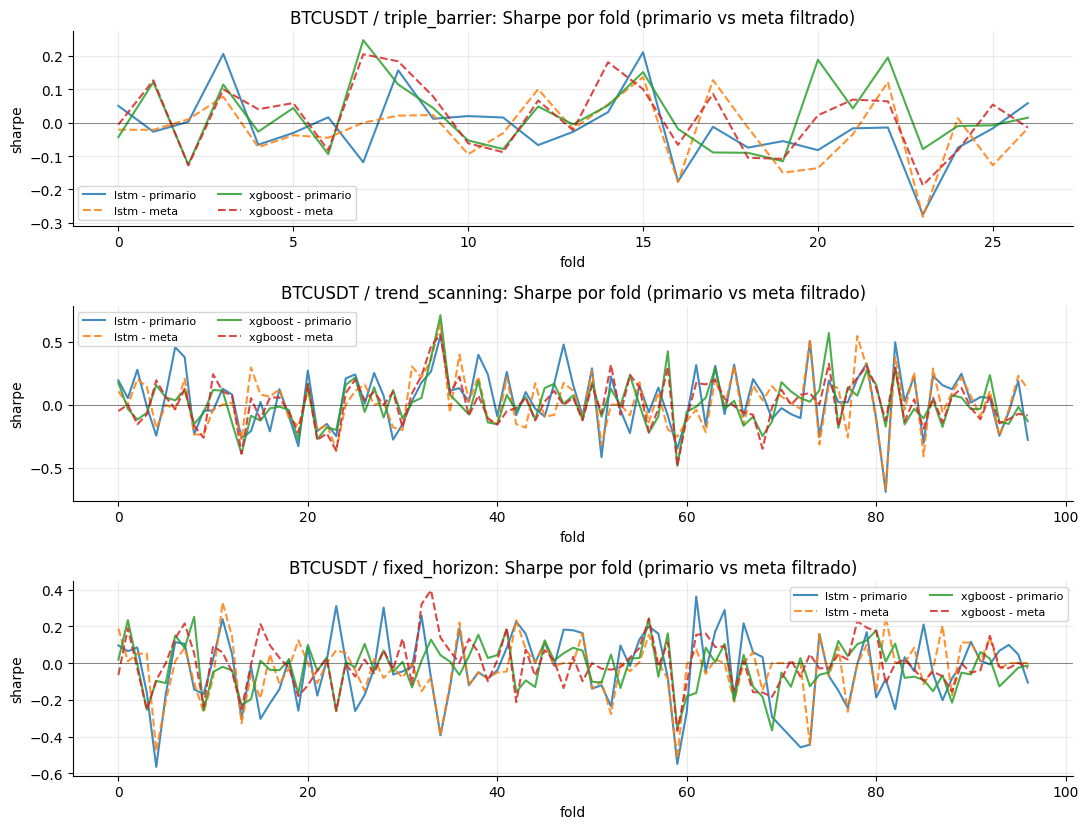

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/lineplots/primary_vs_meta_ethusdt.png


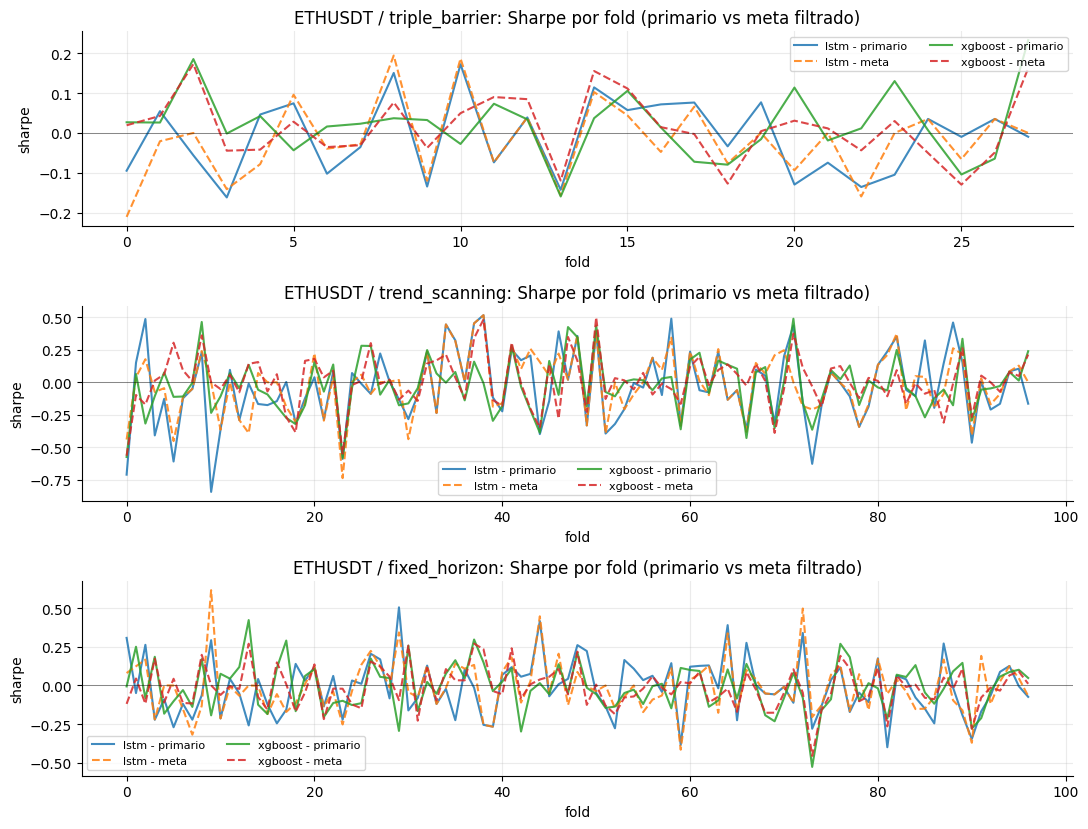

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/lineplots/primary_vs_meta_bnbusdt.png


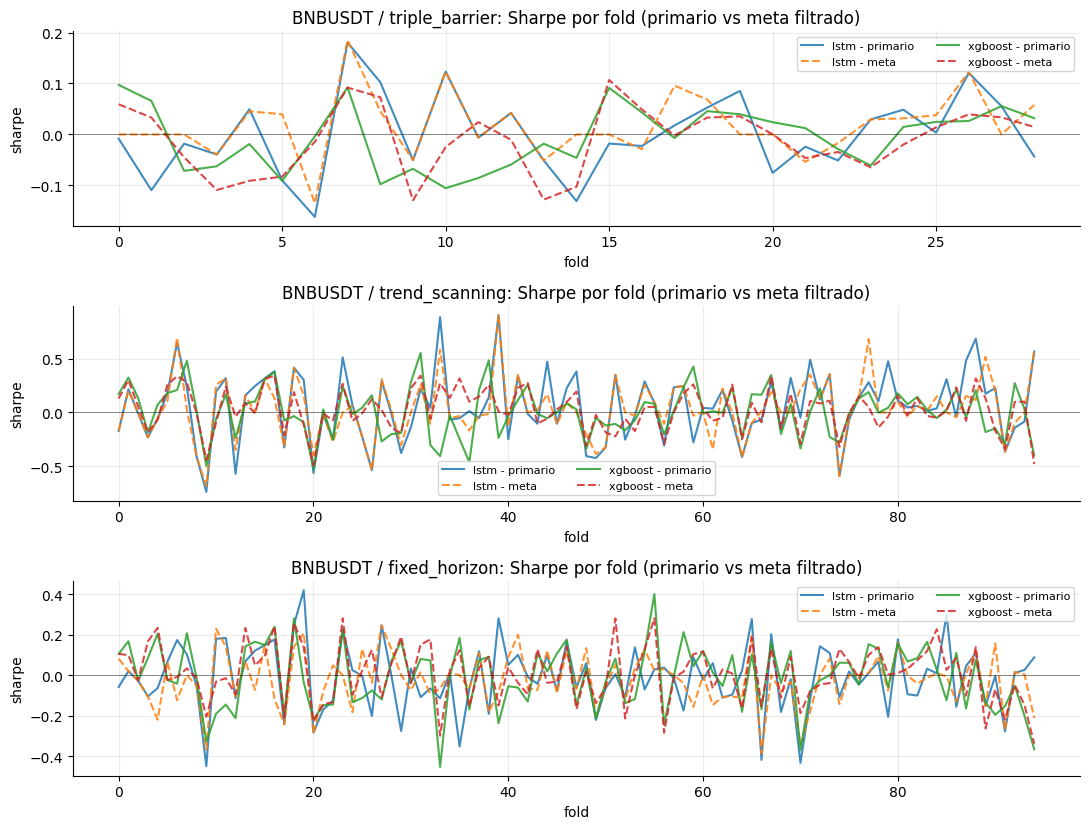

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/lineplots/primary_vs_meta_xrpusdt.png


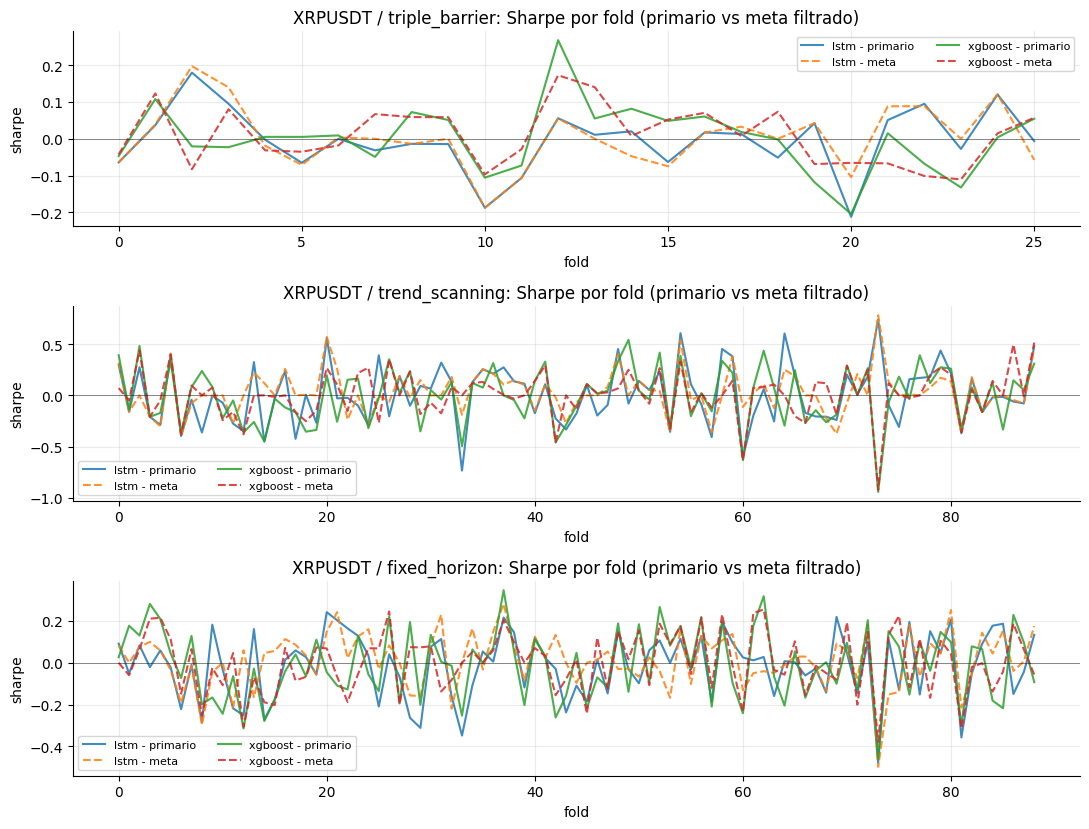

figura guardada -> /app/reports/validation/experiments/meta_labeling_shortlist_evidence/figures/fold_meta_robustness/lineplots/primary_vs_meta_solusdt.png


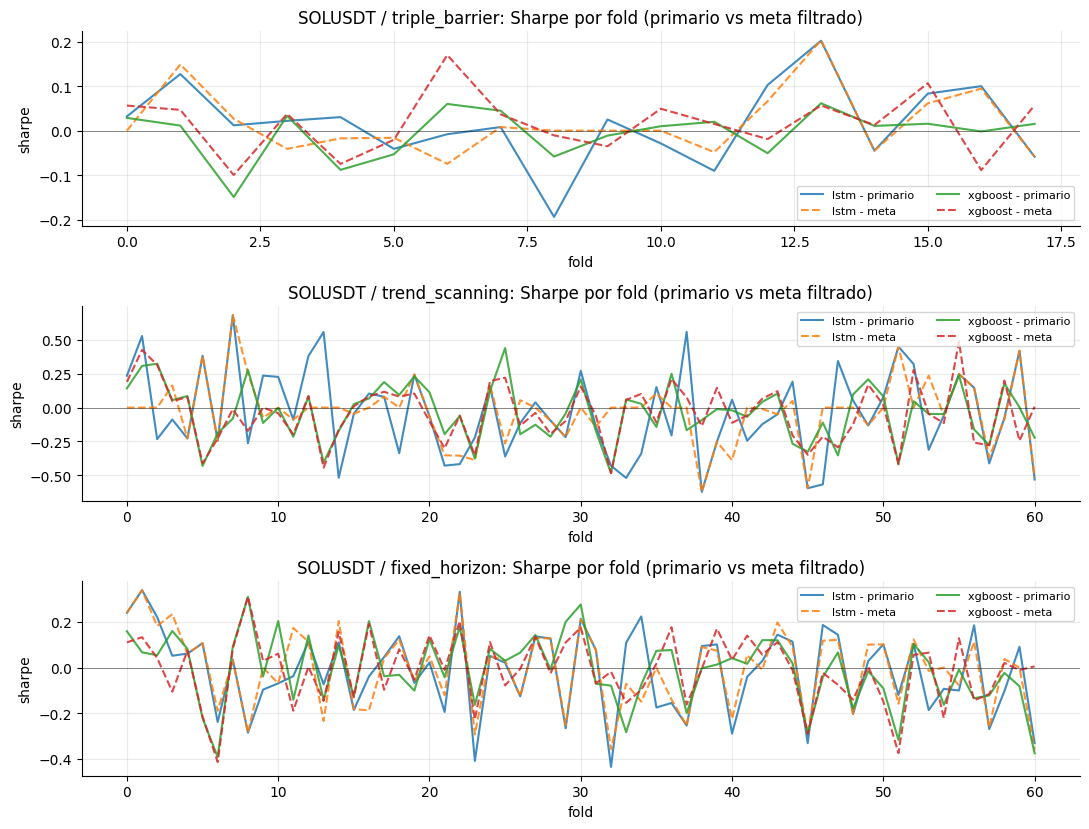

In [8]:
def trayectorias_por_simbolo(df_fold: pd.DataFrame, simbolo: str):
    sub = df_fold[df_fold["symbol"] == simbolo]
    if sub.empty:
        return None
    metodos = [m for m in EXPECTED_METHODS if m in set(sub["method"])]
    if not metodos:
        return None
    fig, axes = plt.subplots(len(metodos), 1, figsize=(11, 2.8 * len(metodos)), sharex=False)
    if len(metodos) == 1:
        axes = [axes]
    for ax, metodo in zip(axes, metodos):
        sub_m = sub[sub["method"] == metodo]
        for familia in sorted(sub_m["primary_family"].dropna().unique()):
            sub_f = sub_m[sub_m["primary_family"] == familia].sort_values("fold")
            ax.plot(sub_f["fold"], sub_f["primary_eligible_sharpe"], label=f"{familia} - primario", linestyle="-", alpha=0.85)
            ax.plot(sub_f["fold"], sub_f["meta_filtered_sharpe"], label=f"{familia} - meta", linestyle="--", alpha=0.85)
        ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
        ax.set_title(f"{simbolo} / {metodo}: Sharpe por fold (primario vs meta filtrado)")
        ax.set_xlabel("fold")
        ax.set_ylabel("sharpe")
        ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    destino = FIG_FOLD / "lineplots" / f"primary_vs_meta_{simbolo.lower()}.png"
    fig.savefig(destino, dpi=160)
    return fig, destino


for simbolo in EXPECTED_SYMBOLS:
    resultado = trayectorias_por_simbolo(fold_rows, simbolo)
    if resultado is None:
        print(f"{simbolo}: sin datos fold-level")
        continue
    fig, destino = resultado
    print(f"figura guardada -> {destino}")
    plt.show()


## 7. Wilcoxon pareado entre familias primarias dentro de la celda

Para cada celda con dos candidatos primarios completados (`xgboost` y `lstm`), se intersectan los `fold` comunes y se aplica Wilcoxon pareado sobre `delta_sharpe` (familia_a vs familia_b). La prueba es estrictamente local a la celda: responde si la familia primaria condiciona la distribución fold del efecto meta, no si una familia es **mejor en media** (eso ya está en `03`).

Resultado en `tables/meta_labeling_shortlist_fold_family_wilcoxon.csv`. Las celdas con una sola familia primaria quedan como `same_family` y no entran al test (situación normal cuando la `shortlist_selection` solo trajo un completed por familia).


In [9]:
try:
    from scipy.stats import wilcoxon
    scipy_disponible = True
except Exception:
    scipy_disponible = False
    print("scipy no disponible: el test no se ejecutara; solo se reportaran medianas.")


def fila_wilcoxon(symbol: str, method: str) -> dict:
    sub = fold_rows[(fold_rows["symbol"] == symbol) & (fold_rows["method"] == method)]
    familias = sorted(sub["primary_family"].dropna().unique())
    out = {
        "symbol": symbol,
        "method": method,
        "family_a": familias[0] if len(familias) >= 1 else None,
        "family_b": familias[1] if len(familias) >= 2 else None,
        "n_pairs": 0,
        "median_diff_a_minus_b": np.nan,
        "statistic": np.nan,
        "p_value": np.nan,
        "verdict": "",
    }
    if len(familias) < 2:
        out["verdict"] = "same_family"
        return out
    pares = (
        sub.pivot_table(index="fold", columns="primary_family", values="delta_sharpe", aggfunc="first")
        .dropna()
    )
    if pares.empty:
        out["verdict"] = "no_paired_folds"
        return out
    diff = pares[familias[0]] - pares[familias[1]]
    out["n_pairs"] = int(len(diff))
    out["median_diff_a_minus_b"] = float(diff.median())
    if not scipy_disponible:
        out["verdict"] = "scipy_unavailable"
        return out
    if (diff == 0).all():
        out["verdict"] = "all_zero_diffs"
        return out
    try:
        res = wilcoxon(diff.to_numpy(), zero_method="wilcox", alternative="two-sided", correction=False)
        out["statistic"] = float(res.statistic)
        out["p_value"] = float(res.pvalue)
        out["verdict"] = "ok"
    except Exception as exc:
        out["verdict"] = f"wilcoxon_error:{exc}"
    return out


filas = []
for s in EXPECTED_SYMBOLS:
    for m in EXPECTED_METHODS:
        filas.append(fila_wilcoxon(s, m))
wilcoxon_df = pd.DataFrame(filas)

csv_wilcoxon = TABLE_DIR / "meta_labeling_shortlist_fold_family_wilcoxon.csv"
wilcoxon_df.to_csv(csv_wilcoxon, index=False)
print(f"CSV escrito: {csv_wilcoxon}")
display_es(wilcoxon_df)


CSV escrito: /app/reports/validation/experiments/meta_labeling_shortlist_evidence/tables/meta_labeling_shortlist_fold_family_wilcoxon.csv


,simbolo,metodo,familia_a,familia_b,n_pares,diff_mediana_a_menos_b,estadistico,p_valor,veredicto
0,BTCUSDT,triple_barrier,lstm,xgboost,27,-0.0237,164.0000,0.5619,ok
1,BTCUSDT,trend_scanning,lstm,xgboost,97,-0.0037,"2,101.0000",0.3215,ok
2,BTCUSDT,fixed_horizon,lstm,xgboost,95,-0.0140,"1,872.0000",0.1299,ok
3,ETHUSDT,triple_barrier,lstm,xgboost,28,-0.0162,195.0000,0.8665,ok
4,ETHUSDT,trend_scanning,lstm,xgboost,97,0.0004,"2,370.0000",0.9813,ok
5,ETHUSDT,fixed_horizon,lstm,xgboost,97,0.0032,"2,288.0000",0.7501,ok
6,BNBUSDT,triple_barrier,lstm,xgboost,29,0.0289,134.0000,0.0724,ok
7,BNBUSDT,trend_scanning,lstm,xgboost,95,0.0155,"2,204.0000",0.9144,ok
8,BNBUSDT,fixed_horizon,lstm,xgboost,95,0.0000,"1,768.0000",0.1097,ok
9,XRPUSDT,triple_barrier,lstm,xgboost,26,-0.0066,159.0000,0.6893,ok


**Lectura.** Veredictos `same_family` indican celdas con un solo candidato primario completado: el test no aplica por diseño del *shortlist* y de la admisión por familia, no es un fallo del notebook. Para celdas `ok` con `p_value` pequeño, la elección de familia primaria altera de forma significativa la distribución fold-level del efecto meta y la lectura agregada del `03` debe matizarse para esa celda; con `p_value` grande, la familia primaria es relativamente intercambiable a efectos del filtro meta.


## 8. Conclusiones

- La auditoría fold-level **no contradice** la lectura del notebook `03`: el `delta_sharpe` agregado es pequeño y heterogéneo, y la dispersión por fold lo confirma con cajas anchas y porcentajes de folds con `delta_sharpe > 0` cercanos a `50 %` en la mayoría de celdas.
- El heatmap de medianas permite identificar celdas con régimen consistentemente favorable o desfavorable al meta-filtro, útiles como casos de estudio cualitativo en memoria.
- Las trayectorias primario vs. meta muestran que el filtro tiende a **seguir** la dinámica del primario, recortando exposición; los giros de signo concentrados en pocos folds explican por qué el efecto medio se diluye.
- El Wilcoxon entre familias primarias dentro de la celda es local y solo aplica donde la corrida trajo dos candidatos completados; los veredictos `same_family` son una propiedad del *shortlist*, no un defecto del análisis.
- La evidencia respalda la tesis editorial del `03`: el meta-labeling se presenta como **capa de filtrado de ejecución verificable**, no como fuente de mejora garantizada de rendimiento. Este notebook añade la auditoría temporal fold a fold que sostiene esa lectura prudente.

**Artefactos exportados** (manifest `reports/validation/experiments/meta_labeling_shortlist_evidence/`):

- Tablas CSV en `tables/`:
  - `meta_labeling_shortlist_fold_delta_summary.csv`
  - `meta_labeling_shortlist_fold_family_wilcoxon.csv`
- Figuras en `figures/fold_meta_robustness/`:
  - `boxplots/` (5 PNG por símbolo)
  - `heatmaps/` (2 PNG: familias `lstm` y `xgboost`)
  - `lineplots/` (5 PNG por símbolo)

**Lectura cruzada:** `03_evidencia_shortlist_meta_labeling.ipynb` (evidencia ejecutiva agregada; mismo manifest; figuras bajo `figures/`).
